# Source position continuous optimisation based on FWI results (test case B and D)

In [2]:
import os

###############################################################################
# Decide on CPU or GPU here
use_gpu = True  # Set to False if you want CPU only
###############################################################################

if use_gpu:
    # Prevent JAX from preallocating most of the GPU memory
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
    # Force JAX to use GPU
    import jax
    jax.config.update("jax_platform_name", "gpu")
else:
    # Force JAX to use CPU
    import jax
    jax.config.update("jax_platform_name", "cpu")

In [3]:
import numpy as np
from jax import jit, vjp, vmap, value_and_grad, random
import jax
from jax import numpy as jnp
from jax import lax
from jaxdf.operators import compose
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, clear_output

from cmcrameri import cm

import optax
import equinox as eqx
from jax.example_libraries import optimizers
import time


from jwave.geometry import Domain, Medium
from jwave.signal_processing import smooth

key = random.PRNGKey(42)  # Random seed


from hybridoed.forward import create_src_field, generate_2D_gridded_src_rec_positions, ricker_wavelet, acoustic2D, acoustic2D_pml, acoustic2D_pml_minmem, acoustic2D_cpml_minmem, acoustic2D_cpml_minmem_strips_diff, acoustic2D_pml_4th_minmem, generate_src_rec_positions, cfl_dt, solve_phi_wave_2d, make_sponge_mask

from hybridoed.oed import *


2026-05-06 13:31:50.441680: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


(500, 1, 70, 70)


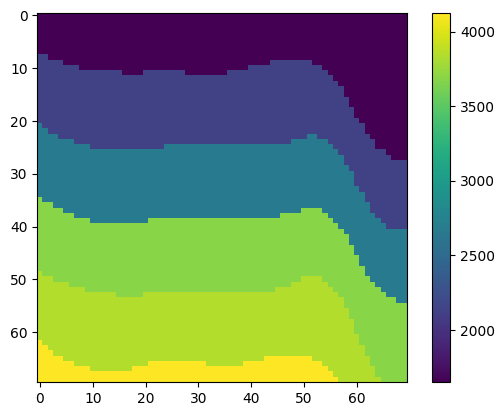

<class 'jaxlib.xla_extension.ArrayImpl'>


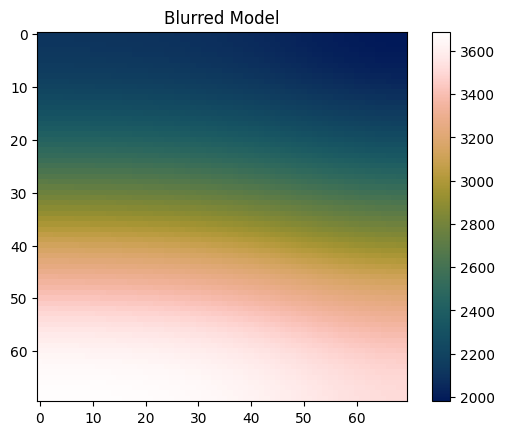

(70, 70)


In [4]:
# Load model

model = jnp.load('model1.npy')

print(model.shape)

model_index = 84

true_model = model[model_index,0,:,:]
# true_model = model
plt.imshow(true_model)
plt.colorbar()
plt.show()
print(type(true_model))

from scipy.ndimage import gaussian_filter

# Apply a Gaussian blur
# Adjust sigma as needed; larger sigma = more blur
blurred_model = gaussian_filter(true_model, sigma=20)

# Visualize the blurred model
plt.figure()
plt.imshow(blurred_model, cmap=cm.batlowW)
plt.colorbar()
plt.title('Blurred Model')
plt.show()
print(blurred_model.shape)

# homogenous model of the velocity avegare

homogenous_model = jnp.ones(true_model.shape) * jnp.mean(true_model)

# plt.imshow(homogenous_model)

In [5]:

# SELECT THE PROPER VARIABLE TO OPTMISE (SRC OR REC). THE ORIGINAL IS OPTIMISE FOR SOURCE (src_coords_list, receiver_coords_list)
# receiver_coords_list, src_coords_list = generate_2D_gridded_src_rec_positions(N=(70, 70), num_sources=5, num_receivers=5)
src_coords_list, receiver_coords_list = generate_2D_gridded_src_rec_positions(N=(70, 70), num_sources=5, num_receivers=5)

# Define your exact desired grid lines:
# src_x = [10.0, 30.0, 50.0]
# src_y = [10.0, 30.0, 50.0]

# rec_x = [5.0, 25.0, 45.0, 65.0]
# rec_y = [5.0, 25.0, 45.0, 65.0]  

# src_coords_list, receiver_coords_list = generate_src_rec_positions(src_x, src_y, rec_x, rec_y)



# num_sources = src_coords_list.shape[0]
sensors_positions = (receiver_coords_list[:,0],receiver_coords_list[:,1])
# sensors = Sensors(positions=sensors_positions)
source_positions = (src_coords_list[:,0],src_coords_list[:,1])

# mask the sensors positions in the domain
# mask = jnp.ones(domain.N)
# mask = mask.at[sensors_positions[0], sensors_positions[1]].set(0.0)

print(sensors_positions)
print(source_positions)

# Drop from 25 sources to approximately 10 sources equally spaced
src_coords_list = src_coords_list[::2]

source_positions = (src_coords_list[:, 0], src_coords_list[:, 1])

# remove again source index 3, 6 and 9 to keep only 10
source_positions = (np.delete(source_positions[0], [3, 6, 9]), np.delete(source_positions[1], [3, 6, 9]))

# # remove again source to keep only 4
# source_positions = (np.delete(source_positions[0], [0,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,22,24]), np.delete(source_positions[1], [0,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,22,24]))

print(len(source_positions[0]))

# source+positions to float values
source_positions = (source_positions[0].astype(float), source_positions[1].astype(float))

# make a reference source position array making rectangular shape around the model
ref_source_positions = (jnp.array([10.0, 30.0, 50.0, 10.0, 50.0, 50.0, 30.0, 30.0, 10.0]), jnp.array([10.0, 30.0, 50.0, 50.0, 10.0, 30.0, 10.0, 50.0, 30.0]))


(Array([12, 12, 12, 12, 12, 23, 23, 23, 23, 23, 35, 35, 35, 35, 35, 46, 46,
       46, 46, 46, 57, 57, 57, 57, 57], dtype=int32), Array([12, 23, 35, 46, 57, 12, 23, 35, 46, 57, 12, 23, 35, 46, 57, 12, 23,
       35, 46, 57, 12, 23, 35, 46, 57], dtype=int32))
(Array([ 5,  5,  5,  5,  5, 20, 20, 20, 20, 20, 35, 35, 35, 35, 35, 50, 50,
       50, 50, 50, 65, 65, 65, 65, 65], dtype=int32), Array([ 5, 20, 35, 50, 65,  5, 20, 35, 50, 65,  5, 20, 35, 50, 65,  5, 20,
       35, 50, 65,  5, 20, 35, 50, 65], dtype=int32))
10


(np.float64(-0.5), np.float64(69.5), np.float64(69.5), np.float64(-0.5))

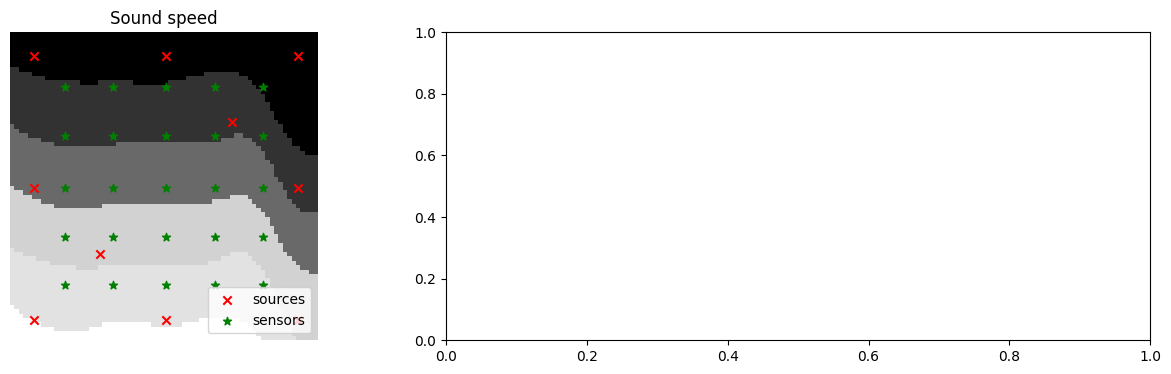

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 2]})

ax[0].imshow(true_model, cmap="gray")
ax[0].scatter(
    source_positions[1], source_positions[0], c="r", marker="x", label="sources"
)
ax[0].scatter(
    sensors_positions[1], sensors_positions[0], c="g", marker="*", label="sensors"
)
ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

# ax[1].plot(signal, label="Source 1", c="k")
# ax[1].set_title("Source signals")
# ax[1].get_yaxis().set_visible(False)

(np.float64(-0.5), np.float64(69.5), np.float64(69.5), np.float64(-0.5))

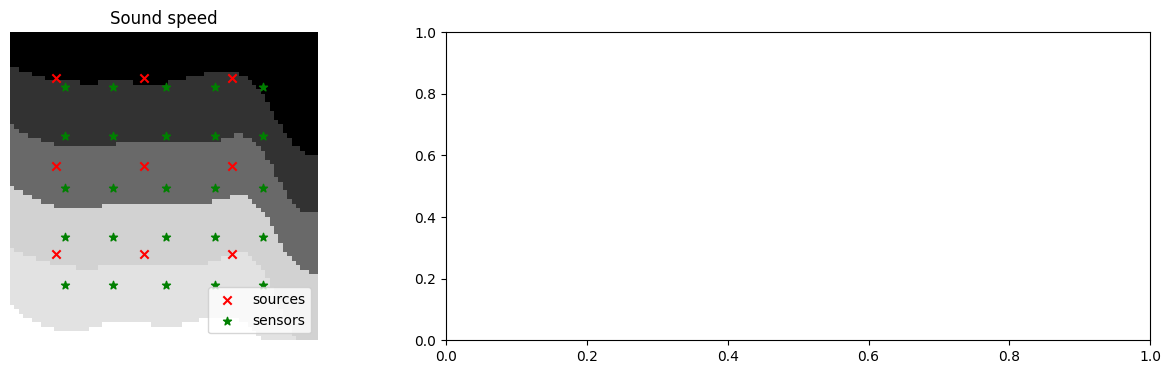

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 2]})

ax[0].imshow(true_model, cmap="gray")
ax[0].scatter(
    ref_source_positions[1], ref_source_positions[0], c="r", marker="x", label="sources"
)
ax[0].scatter(
    sensors_positions[1], sensors_positions[0], c="g", marker="*", label="sensors"
)
ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

# ax[1].plot(signal, label="Source 1", c="k")
# ax[1].set_title("Source signals")
# ax[1].get_yaxis().set_visible(False)

In [8]:
f0 = 200
dx = dy = 0.8
dt_ben = 12e-5
# n_steps_forward = int(326 * 3.63)
n_steps_forward = int(326 * 0.8)

density = jnp.ones_like(true_model) * 1000.0
pml_width = 4

# transform the sensors positions to the the same format as the receiver_is
receiver_is_modif = jnp.stack([sensors_positions[0], sensors_positions[1]], axis=-1)
source_modif = jnp.stack([source_positions[0], source_positions[1]], axis=-1)
num_sources = source_modif.shape[0]


ref_source_positions_modif = jnp.stack([ref_source_positions[0], ref_source_positions[1]], axis=-1)

# make the y coordinate 70 - y coordinate (seond value of the tuple)
# receiver_is_modif = jnp.stack([receiver_is_modif[:,0], 70 - receiver_is_modif[:,1]], axis=-1)
# source_modif = jnp.stack([source_modif[:,0], 70 - source_modif[:,1]], axis=-1)
# print(source_modif,receiver_is_modif)


# Use vmap to simulate wave propagation for all sources
# simulate_for_source = lambda source_i: acoustic2D(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif)
# simulate_for_source = lambda source_i: acoustic2D_pml_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif, pml_width=pml_width)
# simulate_for_source = lambda source_i: acoustic2D_pml_4th_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif, pml_width=10)
# p_data_true, wavefields = vmap(simulate_for_source)(source_modif)

model = homogenous_model

p_test_pml, wavefields_test_pml = acoustic2D_pml_minmem(model, density, source_modif[3], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)
p_test_ref_pml, wavefields_test_ref_pml = acoustic2D_pml_minmem(model, density, ref_source_positions_modif[1], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)


# p_test_cpml, wavefields_test_cpml = acoustic2D_cpml_minmem(model, density, source_modif[3], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)
# p_test_ref_cpml, wavefields_test_ref_cpml = acoustic2D_cpml_minmem(model, density, ref_source_positions_modif[1], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)

# p_test_cpml_stripped, wavefields_test_cpml_strip = acoustic2D_cpml_minmem_strips_diff(model, density, source_modif[3], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)
# p_test_ref_cpml_strip, wavefields_test_ref_cpml_strip = acoustic2D_cpml_minmem_strips_diff(model, density, ref_source_positions_modif[1], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)

# c: (nx,ny) velocity model [m/s]

# dt = cfl_dt(model, (dx, dy), cfl=0.45)
# print(f"Chosen time step: {dt:.2e} seconds")

# # arbitrary wavelet array (you can pass literally anything)
# time = jnp.arange(n_steps_forward) * dt
# my_wavelet_array = ricker_wavelet(time, f0*1.5,0.004)  # (nt,)
# plt.plot(my_wavelet_array)
# wavelet = jnp.asarray(my_wavelet_array, dtype=jnp.float32)  # (nt,)


# # # optional sponge
# mask = make_sponge_mask(model.shape, width=10, strength=0.01)

# out = solve_phi_wave_2d(
#     c=model,                 # (nx, ny) velocity model [m/s]
#     rho=density,                 # or None
#     spacing=(dx, dy),
#     dt=float(dt),
#     source_xy=source_modif[3],  # (2,) source position in grid coordinates (y,x)
#     source_wavelet=wavelet,
#     receiver_xy=receiver_is_modif,  # (n_receivers, 2) receiver positions in grid coordinates (y,x)
#     sponge_mask=mask,
# )
print(p_test_pml.shape)

(260, 25)


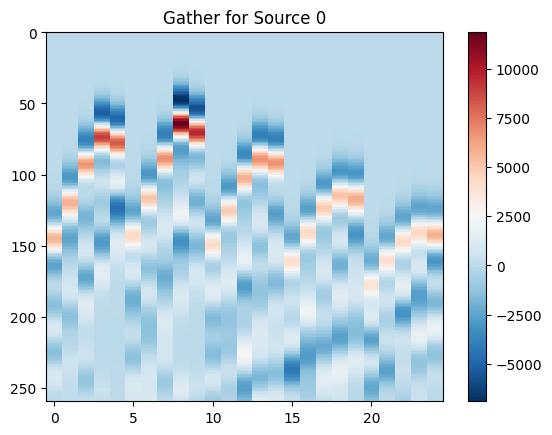

(260, 25)


In [9]:
# plot the gather for the first source
# minimum = np.amin(p_data_true[12])
plt.imshow((p_test_pml), cmap="RdBu_r", interpolation="nearest", aspect="auto")
plt.colorbar()
plt.title('Gather for Source 0')
plt.show()
print(p_test_pml.shape)

In [10]:
fcn_params = {
    "criterion_threshold": 1e-10,
    "regularisation_loss": 0.0,
    "norm_loss": 0.0,
    "top_k_loss": 0.0,
    "differentiable_mask_sharpness": 10.0,
    "number_of_k":10,
    "hidden_size": 56,
    "num_hidden_layers": 3,
    "learning_rate": 2e-2,
    "num_iterations": 15,
    "print_gradients": False,
    "num_sources": num_sources,
}

In [11]:
# Differentiable Mask
def differentiable_mask(probabilities, sharpness=10.0):
    return jax.nn.sigmoid(sharpness * (probabilities - 0.5))

# def top_k_regularization(soft_mask, k=10):
#     top_k_values = jax.lax.top_k(soft_mask, k)[0]
#     penalty = jnp.sum(soft_mask) - jnp.sum(top_k_values)
#     return penalty

def smooth_fun(gradient):
    # x = gradient.on_grid[..., 0]
    x = gradient
    for _ in range(1):
        x = smooth(x)
    return x
@jit
def fwi(src_position):
    print("source position in fwi", src_position)
    num_steps_fwi = 80 # for pml implementation
    # num_steps_fwi = 80 # for cpml implementation
    key = random.PRNGKey(42)
    _, key = random.split(key)
    # initial model is the blurred model
    # params_fwi = blurred_model

    def simulate_true(src):
        p_rec, _ = acoustic2D_pml_minmem(
            true_model, density, src,
            f0, dx, dy, dt_ben, n_steps_forward,
            receiver_is_modif, pml_width=pml_width, output_wavefield=True
        )
        return p_rec

    p_data_obs = vmap(simulate_true)(src_position)  # [Nsrc, Nt, Nrec] is equivalent to making a measurements of the True model with the initial position once every start of the FWI loop

    init_fun_fwi, update_fun_fwi, get_params_fwi = optimizers.adam(25.0, 0.9, 0.9)
    opt_state_fwi = init_fun_fwi(blurred_model)
    # opt_state_fwi = init_fun_fwi(homogenous_model)

    # print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

    def loss_func_fwi(opt_state_fwi, src_num):
        @jit
        def simulate_one(src_num):
            p_rec, _ = acoustic2D_pml_minmem(
                opt_state_fwi, density, src_position[src_num],
                f0, dx, dy, dt_ben, n_steps_forward,
                receiver_is_modif, pml_width=pml_width, output_wavefield=True
            )
            return p_rec
        
        # simulate_all = jit(vmap(simulate_one))
        # p_pred = simulate_all(src_position)
        # p_pred,_ = acoustic2D_pml_minmem(params_fwi, density, src_position[src_num], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)
        p_pred = simulate_one(src_num)

        data = p_data_obs[src_num]

        print(p_pred.shape, data.shape)
        return jnp.mean((p_pred - data) ** 2)

    loss_with_grad_fwi = value_and_grad(loss_func_fwi,argnums=0)

    # Define and compile the update function
    @jit
    def update_fwi(opt_state, key, k):
        v = get_params_fwi(opt_state)
        src_num = random.choice(key, num_sources)
        lossval, gradient = loss_with_grad_fwi(v, src_num)
        gradient = smooth_fun(gradient)
        # gradient *= probabilities[src_num]
        return lossval, update_fun_fwi(k, gradient, opt_state)

    @jit
    def body(carry, k):
        opt_state, key = carry
        _, key = random.split(key)      # throw away first, keep second
        lossval, opt_state = update_fwi(opt_state, key, k)
        return (opt_state, key), lossval

    (opt_state_fwi, _), losses = lax.scan(body, (opt_state_fwi, key), jnp.arange(num_steps_fwi))
    new_params = get_params_fwi(opt_state_fwi)

    return new_params 


nx, ny = true_model.shape

# we’ll clamp i ∈ [pml, nx-1-pml], j ∈ [pml, ny-1-pml]
@jit
def clamp_sources(src):
    i_clamped = jnp.clip(src[:,0], pml_width, nx - 1 - pml_width)
    j_clamped = jnp.clip(src[:,1], pml_width, ny - 1 - pml_width)
    return jnp.stack([i_clamped, j_clamped], axis=-1)

In [12]:
simulate_for_source = lambda source_i: acoustic2D_pml_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width, output_wavefield=True)
#     # simulate_for_source = lambda source_i: acoustic2D_pml_4th_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif, pml_width=10)
p_data_true, _ = vmap(simulate_for_source)(source_modif)
print(len(p_data_true))

10


source position in fwi Traced<ShapedArray(float32[10,2])>with<DynamicJaxprTrace(level=1/0)>
(260, 25) (260, 25)


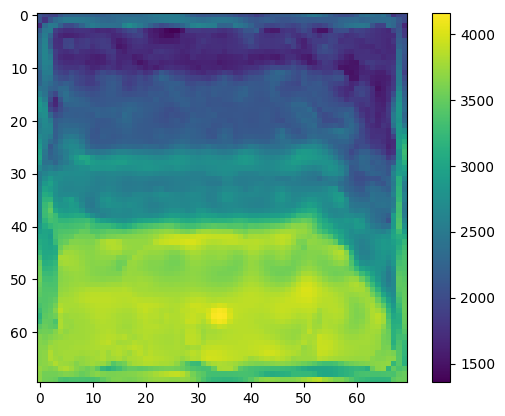

44363.227


In [13]:
iin = fwi(source_modif)
plt.imshow(iin)
plt.colorbar()
plt.show()
# L1 loss
print(jnp.linalg.norm((iin - jnp.fliplr(true_model)), ord=1))

source position in fwi Traced<ShapedArray(float32[9,2])>with<DynamicJaxprTrace(level=1/0)>
(260, 25) (260, 25)


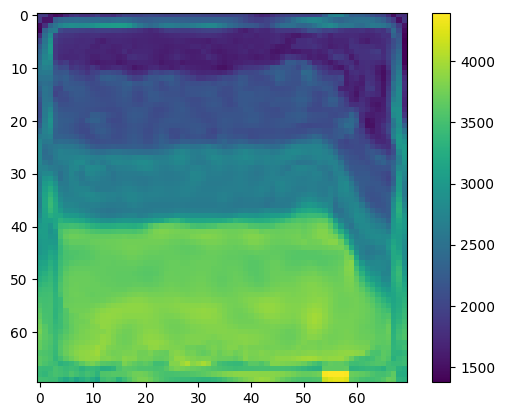

49526.844


In [14]:
iin = fwi(ref_source_positions_modif)
plt.imshow(iin)
plt.colorbar()
plt.show()
# L1 loss
print(jnp.linalg.norm((iin - jnp.fliplr(true_model)), ord=1))

In [15]:
# Differentiable Loss Function for the optimizer
def outer_loss(args):
    # probabilities = model(x)  # Predict probabilities
    # soft_mask = differentiable_mask(probabilities, sharpness)  # Generate soft mask
    
    

    # multiplier = matrix.shape[0] // soft_mask.shape[0]
    # soft_mask = jnp.repeat(soft_mask, multiplier, axis=0)

    # weighted_matrix = soft_mask[:, None] * matrix  # Apply mask to matrix rows

    # regularization_loss = mask_penalty * jnp.mean(soft_mask * (1 - soft_mask))  # Encourage binary mask
    # norm_loss = jnp.linalg.norm(soft_mask, ord=1)
    # top_k_loss = top_k_regularization(soft_mask, k=fcn_params["number_of_k"])

    # singular_loss = eigenvalue_criterion(weighted_matrix, threshold=criterion_threshold)
    inverted_model = fwi(args)
    def simulate_rec(src):
        p_rec, _ = acoustic2D_pml_minmem(
            inverted_model, density, src,
            f0, dx, dy, dt_ben, n_steps_forward,
            receiver_is_modif, pml_width=pml_width, output_wavefield=True
        )
        return p_rec

    # p_pred = vmap(simulate_rec)(ref_source_positions_modif)
    # simulate_for_source_actual_model = lambda source_i: acoustic2D_pml_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width, output_wavefield=True)
    # ref_data, _ = vmap(simulate_for_source_actual_model)(ref_source_positions_modif)

    # fwi_loss = jnp.linalg.norm((inverted_model - true_model), ord=1)
    fwi_loss = jnp.mean((inverted_model - true_model) ** 2)
    # data_loss = jnp.mean((p_pred - ref_data) ** 2)

    # fwi_loss = lossval

    # logs["models"].append(inverted_model)


    # return -(singular_loss) + params["regularisation_loss"]*regularization_loss + params["norm_loss"]*norm_loss + params["top_k_loss"]*top_k_loss
    return fwi_loss #+ fcn_params["regularisation_loss"]*regularization_loss + fcn_params["norm_loss"]*norm_loss 
    # return data_loss




In [16]:
n_illum_probes = 16
illum_beta = 0.067
alpha_strength = 0.05
illum_eps = 1e-12


def smooth_fun(gradient):
    x = gradient
    for _ in range(1):
        x = smooth(x)
    return x


def simulate_one_source(model, src):
    p_rec, _ = acoustic2D_pml_minmem(
        model,
        density,
        src,
        f0,
        dx,
        dy,
        dt_ben,
        n_steps_forward,
        receiver_is_modif,
        pml_width=pml_width,
        output_wavefield=True,
    )
    return p_rec


def jt_random_probe(model, src, key):
    """
    Estimate one stochastic contribution to diag(J^T J)
    using a single source and one random data-space probe.
    """

    # Forward once only to get shape and define VJP
    y, vjp_fun = jax.vjp(
        lambda m: simulate_one_source(m, src),
        model,
    )

    q = random.rademacher(key, y.shape).astype(y.dtype)
    q = q / jnp.sqrt(q.size)

    g = vjp_fun(q)[0]  # J^T q

    return g**2


# @jit

# def outer_loss(src_positions):

#     src_positions = clamp_sources(src_positions)

#     key = random.PRNGKey(123)

#     def one_source(src_num):

#         src = src_positions[src_num]

#         def one_probe(k):

#             illum = jt_random_probe(blurred_model, src, k)

#             return illum

#         keys = random.split(

#             random.fold_in(key, src_num),

#             n_illum_probes,

#         )

#         illum_source = jnp.mean(vmap(one_probe)(keys), axis=0)

#         return illum_source

#     illum_sources = vmap(one_source)(jnp.arange(num_sources))

#     illum = jnp.mean(illum_sources, axis=0)

#     illum = smooth_fun(illum)

#     mean_illum = jnp.mean(illum)

#     total_loss = -mean_illum

#     normalized_illum = illum / (mean_illum + illum_eps)

#     uniformity_loss = jnp.var(normalized_illum)
#     mean_illum = jnp.mean(illum)


#     # Prevent uniformly low illumination

#     strength_loss = -jnp.log(mean_illum + illum_eps)

#     return uniformity_loss + alpha_strength * strength_loss

#     # return total_loss + illum_beta * uniformity_loss
#     # return uniformity_loss

In [17]:
# @partial(jit, static_argnums=(1))
@jit
def outer_step(fargs, state):

    # Print gradients for debugging
    def print_grads(grads):
        print("Gradients in step function:")

        def print_leaf(x):
            if x is None:
                print("None")
            else:
                print(x)
        jax.tree_util.tree_map(print_leaf, grads)


    loss, grad_src = jax.value_and_grad(outer_loss)(fargs)
    updates, state = outer_optimiser.update(grad_src, state)
    fargs = optax.apply_updates(fargs, updates)

    fargs = clamp_sources(fargs)
    
    return fargs, state, loss

In [18]:
fargs = source_modif
outer_optimiser = optax.adam(learning_rate=2.0)
opt_state = outer_optimiser.init(eqx.filter(fargs, eqx.is_array))
n_steps_outer = 50


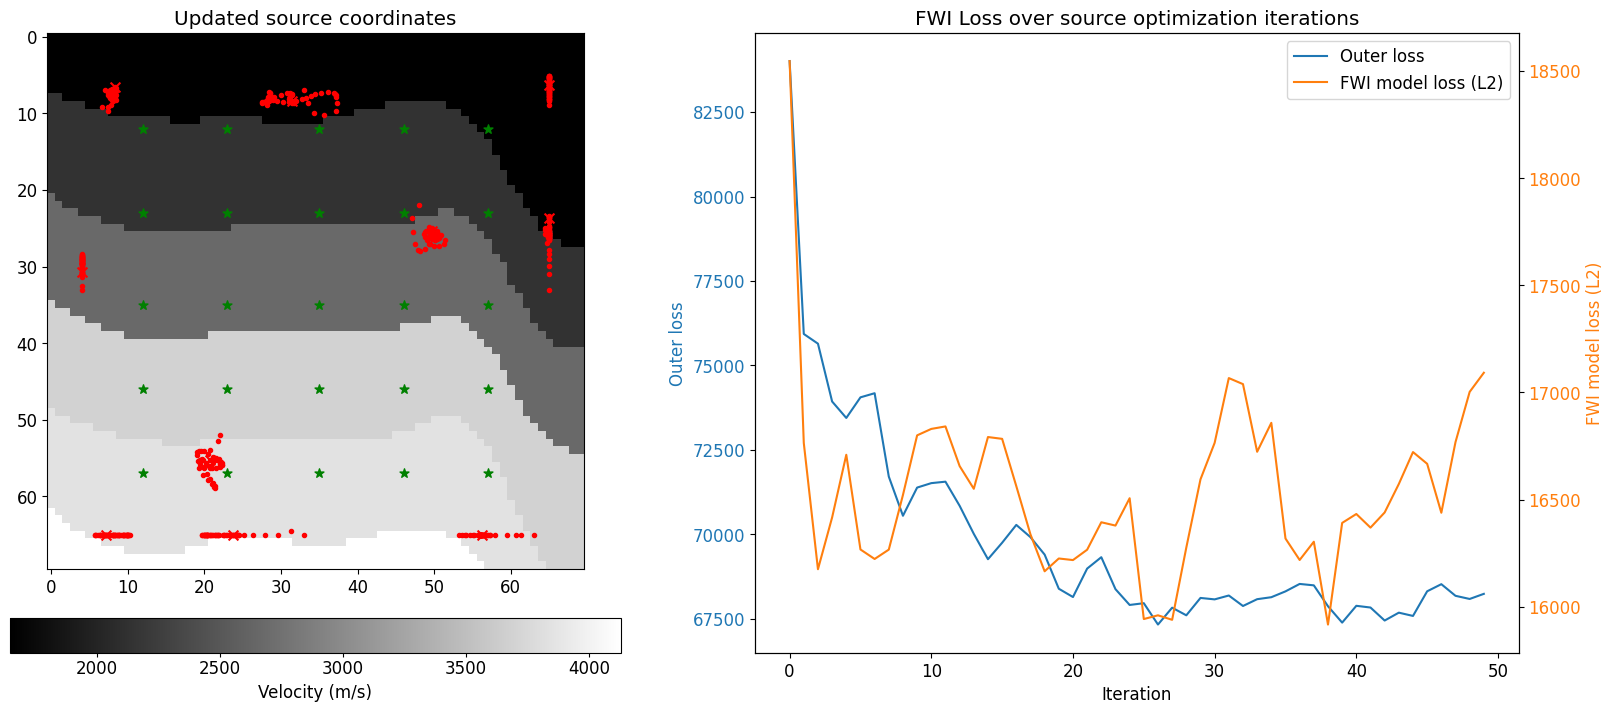

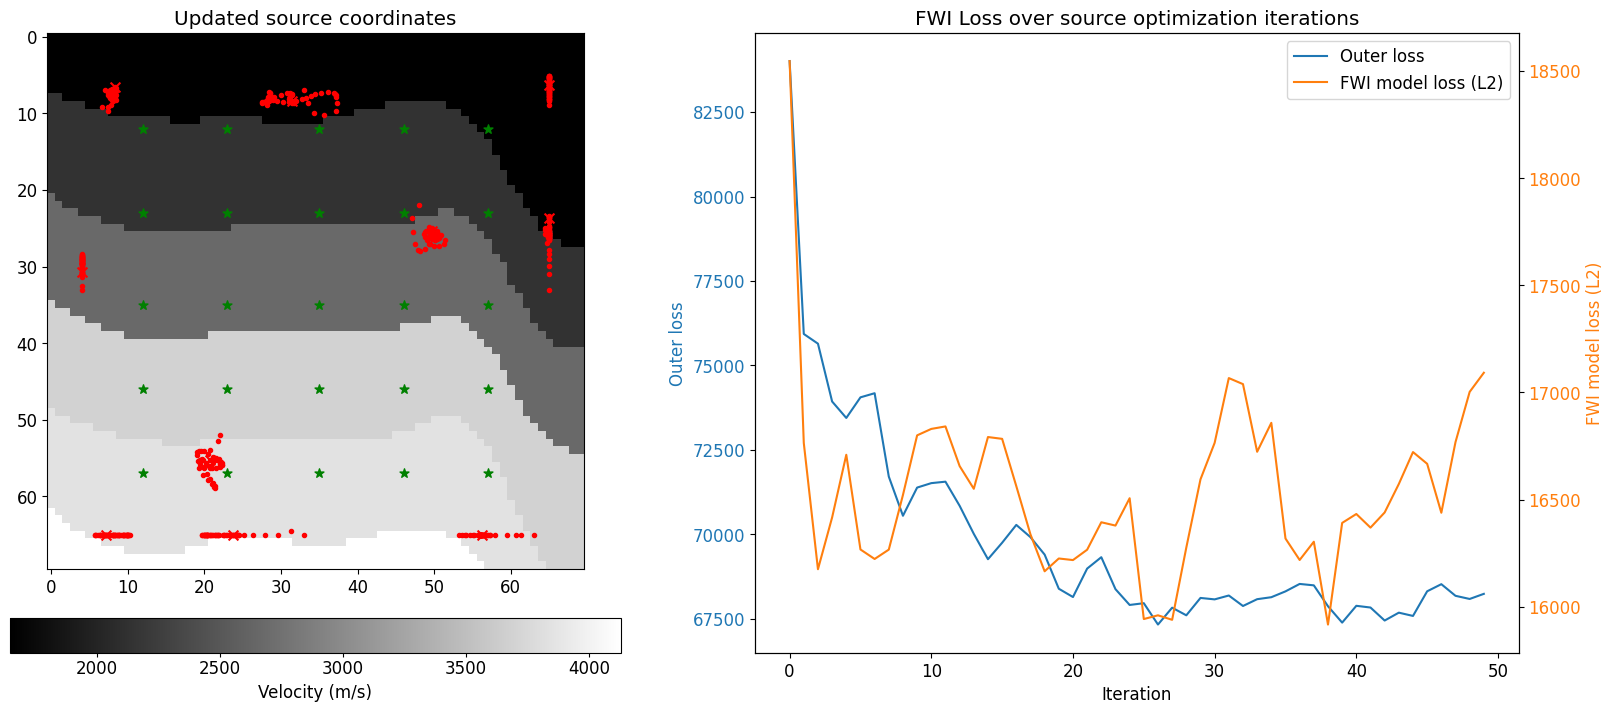

Final Loss: 68239.81


In [19]:
font_size = 12
plt.rcParams.update({'font.size': font_size})

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# --- Figure with horizontal colorbar under the LEFT plot ---
fig = plt.figure(figsize=(16, 7), layout="constrained")
axs = fig.subplot_mosaic(
    [["left", "right"],
     ["cbar", "right"]],
    width_ratios=[0.8, 1],
    height_ratios=[1, 0.065],   # adjust (e.g., 0.08–0.12) if you want a thinner/thicker cbar
)
fig.set_constrained_layout_pads(
    w_pad=2/72,   # outer horizontal padding (inches)
    h_pad=2/72,   # outer vertical padding
    wspace=0.15,  # extra space between left/right panels
    hspace=0.02
)

ax1  = axs["left"]
ax2  = axs["right"]
cax  = axs["cbar"]   # dedicated axes for the horizontal colorbar under the left plot

# Make LEFT and RIGHT plots square (axes box, not data ratio)
ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# Base image (fixed) + single, persistent colorbar (horizontal, under left)
im   = ax1.imshow(true_model, cmap="gray", interpolation="nearest", aspect="equal")
cbar = fig.colorbar(im, cax=cax, orientation="horizontal", label="Velocity (m/s)")
cbar.ax.tick_params(length=3, pad=2)
ax1.set_title("Updated source coordinates")

# Persistent loss lines (two y-axes)
(line_loss,) = ax2.plot([], [], label="Outer loss", color="tab:blue")
ax2.set_title("FWI Loss over source optimization iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Outer loss", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax2b = ax2.twinx()
(line_fwi,) = ax2b.plot([], [], label="FWI model loss (L2)", color="tab:orange")
ax2b.set_ylabel("FWI model loss (L2)", color="tab:orange")
ax2b.tick_params(axis="y", labelcolor="tab:orange")

# Combined legend
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="upper right")

lossvals = []
fwi_loss_vals = []
source_trajectories = []
receiver_trajectories = []

def clear_overlays(ax):
    for ln in ax.lines[:]:
        ln.remove()
    for coll in ax.collections[:]:
        coll.remove()
    for p in ax.patches[:]:
        p.remove()

for i in range(n_steps_outer):
    tic = time.time()
    fargs, opt_state, lossval = outer_step(fargs, opt_state)
    lossvals.append(lossval)
    print(f"Step {i}, Loss: {lossval}, Time: {time.time() - tic:.3f}s")

    inverted_model = fwi(fargs)
    # remove the pml from the mdoel for the loss calculation
    inverted_model_no_pml = inverted_model[pml_width:-pml_width, pml_width:-pml_width]
    true_model_no_pml = true_model[pml_width:-pml_width, pml_width:-pml_width]
    fwi_loss = jnp.mean((inverted_model_no_pml - true_model_no_pml) ** 2)
    fwi_loss_vals.append(fwi_loss)


    source_trajectories.append(fargs)
    receiver_trajectories.append(receiver_is_modif)

    # Update overlays on the left (image & colorbar persist)
    clear_overlays(ax1)
    for traj in source_trajectories:
        ax1.scatter(*traj.T[::-1], s=35, marker='.', color='r')
    for rec in receiver_is_modif:
        ax1.scatter(*rec.T[::-1], s=45, marker='*', color='g')
    for src in fargs:
        ax1.scatter(*src.T[::-1], s=50, marker='x', color='r')

    # Update loss line (axes stays square due to box aspect)
    line_fwi.set_data(range(len(fwi_loss_vals)), fwi_loss_vals)
    line_loss.set_data(range(len(lossvals)), lossvals)

    ax2.relim()
    ax2b.relim()
    ax2.autoscale_view()
    ax2b.autoscale_view()

    clear_output(wait=True)
    display(fig)
    fig.canvas.draw_idle()
    # fig.savefig(f"opti_movie/step_{i}.png")  # keep default bbox to preserve layout

plt.show()
print("Final Loss:", lossvals[-1])

# Save results
# np.save('source_trajectories.npy', np.array(source_trajectories, dtype=object))
# np.save('receiver_trajectories.npy', np.array(receiver_trajectories, dtype=object))
# np.save('lossvals.npy', np.array(lossvals))

In [19]:
final_model = fwi(fargs)
initial_model = fwi(source_modif)

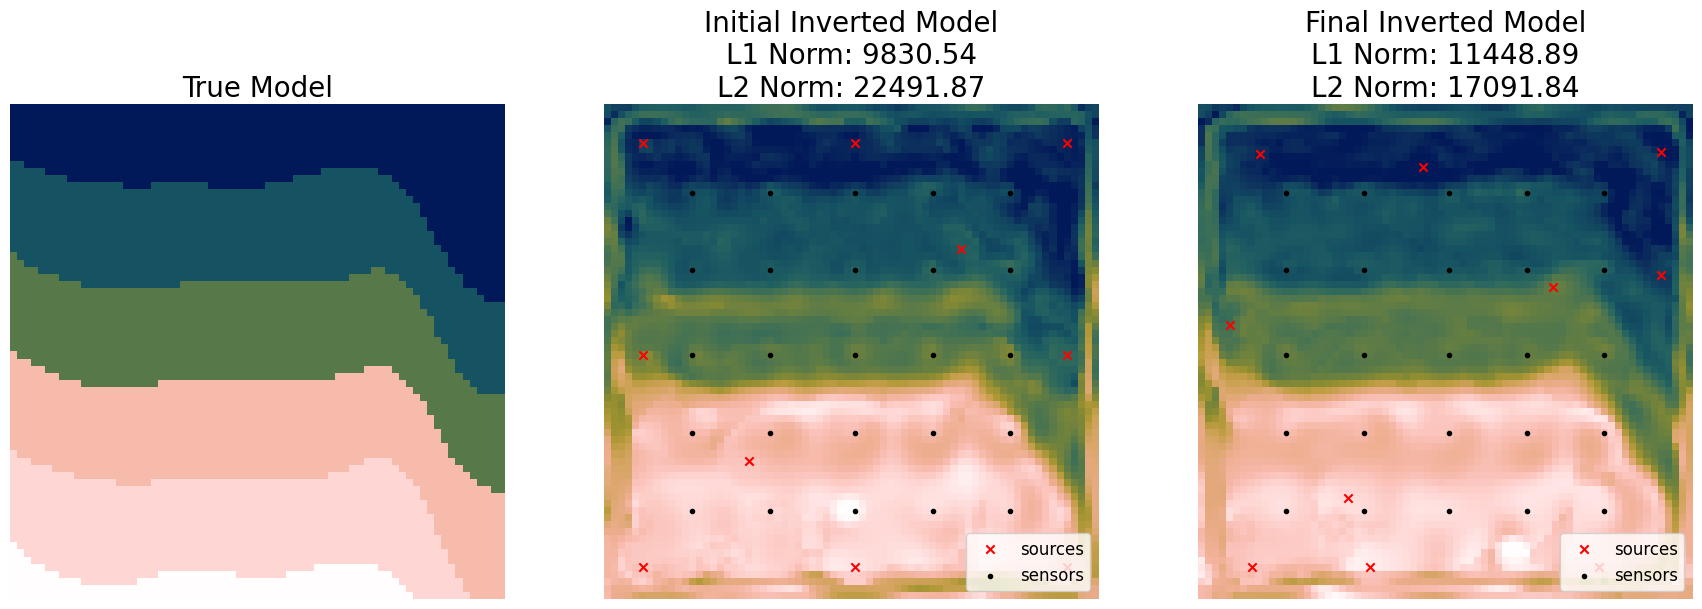

In [20]:

vmin, vmax = true_model.min(), true_model.max()

initial_model_no_pml = initial_model[pml_width:-pml_width, pml_width:-pml_width]
final_model_no_pml = final_model[pml_width:-pml_width, pml_width:-pml_width]
true_model_no_pml = true_model[pml_width:-pml_width, pml_width:-pml_width]

l1_norm_initial = jnp.linalg.norm((initial_model_no_pml - true_model_no_pml), ord=1)
l1_norm_final = jnp.linalg.norm((final_model_no_pml - true_model_no_pml), ord=1)

# l2_norm_initial = jnp.linalg.norm((initial_model_no_pml - true_model_no_pml), ord=2)
# l2_norm_final = jnp.linalg.norm((final_model_no_pml - true_model_no_pml), ord=2)

l2_norm_initial = (jnp.mean((initial_model_no_pml - true_model_no_pml) ** 2))
l2_norm_final = (jnp.mean((final_model_no_pml - true_model_no_pml) ** 2))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot the true model
im = axes[0].imshow(true_model, cmap=cm.batlowW, vmin=vmin, vmax=vmax)
axes[0].set_title('True Model', fontsize=20)
axes[0].axis('off')
# fig.colorbar(im, ax=axes[0], orientation='vertical')

# Plot the initial inverted model
im = axes[1].imshow(initial_model, cmap=cm.batlowW, vmin=vmin, vmax=vmax)
axes[1].scatter(source_positions[1], source_positions[0], c="r", marker="x", label="sources")
axes[1].scatter(sensors_positions[1], sensors_positions[0], c="k", marker=".", label="sensors")
axes[1].set_title(f'Initial Inverted Model\nL1 Norm: {l1_norm_initial:.2f}\nL2 Norm: {l2_norm_initial:.2f}', fontsize=20)
axes[1].axis('off')
axes[1].legend(loc="lower right")
# fig.colorbar(im, ax=axes[1], orientation='vertical')

# Plot the final inverted model
im = axes[2].imshow(final_model, cmap=cm.batlowW, vmin=vmin, vmax=vmax)
axes[2].scatter(fargs[:,1], fargs[:,0], c="r", marker="x", label="sources")
axes[2].scatter(sensors_positions[1], sensors_positions[0], c="k", marker=".", label="sensors")
axes[2].set_title(f'Final Inverted Model\nL1 Norm: {l1_norm_final:.2f}\nL2 Norm: {l2_norm_final:.2f}', fontsize=20)
axes[2].axis('off')
axes[2].legend(loc="lower right")
# fig.colorbar(im, ax=axes[2], orientation='vertical')

plt.tight_layout()
# plt.show()


In [21]:
# Look at the initial, final  layout traces and true model traces
# source_idx = 0
# trace_index = 5

# p_true, wavefields_ini = acoustic2D_cpml_minmem(true_model, density, ref_source_positions_modif[source_idx], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)

# p_ini, wavefields_ini = acoustic2D_cpml_minmem(initial_model, density, ref_source_positions_modif[source_idx], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)

# p_final, wavefields_final = acoustic2D_cpml_minmem(final_model, density, ref_source_positions_modif[source_idx], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)



# print(p_ini.shape)

# # plot a few traces
# plt.figure(figsize=(12, 6))
# plt.plot(p_ini[ :, trace_index], label='Initial Inverted Model')
# plt.plot(p_final[ :, trace_index], label='Final Inverted Model')
# plt.plot(p_true[ :, trace_index], label='True Model')
# plt.grid()
# plt.legend()
# plt.show()


In [22]:
print(fargs)

[[10.307794  5.634224]
 [ 7.581152 31.234346]
 [17.309242 44.49434 ]
 [16.002441 30.885283]
 [18.913633 10.455734]
 [15.385533 65.      ]
 [13.082933 13.131409]
 [22.99288  46.18149 ]
 [12.897218 50.837593]
 [62.060863 61.274765]]


In [23]:
# write the fargs to a numpy file for easy reading
# np.save('optimized_source_positions_testcaseBD_dataloss.npy', np.array(fargs))


In [24]:
# # can you generate a movie of the pictures of the optimization steps?
# import imageio
# import glob
# import re
# images = []
# # Ensure images are loaded in numerical order

# def extract_step_number(fname):
#     match = re.search(r"step_(\d+)\.png", fname)
#     return int(match.group(1)) if match else -1

# file_list = sorted(glob.glob("opti_movie/step_*.png"), key=extract_step_number)
# for filename in file_list:
#     images.append(imageio.imread(filename))
# imageio.mimsave('optimization_steps.gif', images, fps=2)

In [25]:
# # Coarse 2-source loss landscape scan.
# # x-axis: scanned coordinate of source_pair[0]
# # y-axis: scanned coordinate of source_pair[1]
# # z/color: objective value returned by landscape_loss_fn

# # Increase this for a finer landscape once the coarse scan looks useful.
# n_landscape_points = 41  # coarse: 9-15, finer: 25-50+

# # Select the two sources with zero-based Python indices and the coordinate component to scan.
# # coordinate_component=0 scans row/depth, coordinate_component=1 scans column/lateral position.
# source_pair = (0, 1)
# coordinate_component = 1

# # Use the current optimized layout as the base; replace with source_modif to scan around the initial layout.
# base_sources = clamp_sources(jnp.array(fargs))

# # Full valid range by default. For a cheaper local landscape, set e.g. landscape_half_width = 10.
# landscape_half_width = None

# valid_min = float(pml_width)
# valid_max = float((nx if coordinate_component == 0 else ny) - 1 - pml_width)

# def scan_bounds(source_idx):
#     center = float(base_sources[source_idx, coordinate_component])
#     if landscape_half_width is None:
#         return valid_min, valid_max
#     return (
#         max(valid_min, center - landscape_half_width),
#         min(valid_max, center + landscape_half_width),
#     )

# src1_min, src1_max = scan_bounds(source_pair[0])
# src2_min, src2_max = scan_bounds(source_pair[1])
# src1_values = np.linspace(src1_min, src1_max, n_landscape_points)
# src2_values = np.linspace(src2_min, src2_max, n_landscape_points)

# # Change this if you want to plot another scalar objective.
# landscape_loss_fn = jit(lambda src_positions: outer_loss(src_positions))

# loss_landscape = np.empty((n_landscape_points, n_landscape_points), dtype=float)
# tic = time.time()

# for i, src1_pos in enumerate(src1_values):
#     for j, src2_pos in enumerate(src2_values):
#         trial_sources = base_sources
#         trial_sources = trial_sources.at[source_pair[0], coordinate_component].set(src1_pos)
#         trial_sources = trial_sources.at[source_pair[1], coordinate_component].set(src2_pos)
#         loss_landscape[i, j] = float(landscape_loss_fn(trial_sources))
#     print(f"Landscape row {i + 1}/{n_landscape_points} done")

# print(f"Computed {n_landscape_points ** 2} loss values in {time.time() - tic:.1f}s")

# loss_landscape_X, loss_landscape_Y = np.meshgrid(src1_values, src2_values, indexing="ij")

# fig = plt.figure(figsize=(12, 9))
# ax = fig.add_subplot(111, projection="3d")
# surf = ax.plot_surface(
#     loss_landscape_X,
#     loss_landscape_Y,
#     loss_landscape,
#     cmap="viridis",
#     edgecolor="none",
#     antialiased=True,
# )
# ax.set_xlabel(f"Source {source_pair[0]} coordinate {coordinate_component}")
# ax.set_ylabel(f"Source {source_pair[1]} coordinate {coordinate_component}")
# ax.set_zlabel("Misfit / objective")
# ax.set_title("2-source loss landscape")
# fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1, label="Misfit / objective")
# plt.tight_layout()
# plt.show()

# # Optional top view, useful for selecting where to run a finer scan.
# plt.figure(figsize=(7, 6))
# plt.contourf(loss_landscape_X, loss_landscape_Y, loss_landscape, levels=30, cmap="viridis")
# plt.scatter(
#     float(base_sources[source_pair[0], coordinate_component]),
#     float(base_sources[source_pair[1], coordinate_component]),
#     c="r",
#     marker="x",
#     label="base layout",
# )
# plt.xlabel(f"Source {source_pair[0]} coordinate {coordinate_component}")
# plt.ylabel(f"Source {source_pair[1]} coordinate {coordinate_component}")
# plt.colorbar(label="Misfit / objective")
# plt.legend()
# plt.tight_layout()
# plt.show()


n_illum_probes=10, illum_beta=0.000, score=8.836396e+04, objective=-1.977990e-04, time=6.0s
n_illum_probes=10, illum_beta=0.011, score=8.251966e+04, objective=8.984244e-03, time=5.9s
n_illum_probes=10, illum_beta=0.022, score=8.517552e+04, objective=1.841608e-02, time=5.9s
n_illum_probes=10, illum_beta=0.033, score=8.604427e+04, objective=2.928984e-02, time=5.8s
n_illum_probes=10, illum_beta=0.044, score=8.166330e+04, objective=3.621755e-02, time=6.0s
n_illum_probes=10, illum_beta=0.056, score=8.300988e+04, objective=4.430780e-02, time=5.9s
n_illum_probes=10, illum_beta=0.067, score=8.441932e+04, objective=5.484677e-02, time=5.8s
n_illum_probes=10, illum_beta=0.078, score=8.518688e+04, objective=6.643323e-02, time=6.0s
n_illum_probes=10, illum_beta=0.089, score=7.702348e+04, objective=7.559342e-02, time=5.8s
n_illum_probes=10, illum_beta=0.100, score=8.352387e+04, objective=8.588571e-02, time=6.0s
n_illum_probes=13, illum_beta=0.000, score=8.979313e+04, objective=-1.908516e-04, time=6.

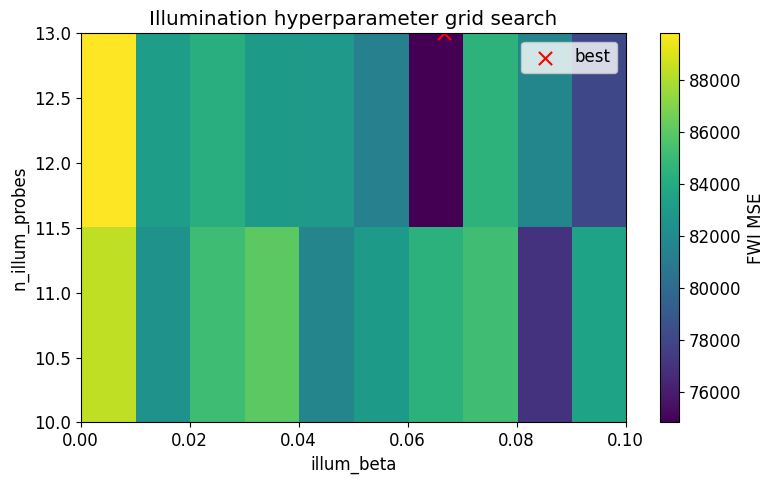

In [16]:
# Grid search for illumination-objective hyperparameters.
# This does not mutate the global illum_beta or n_illum_probes used above.

probe_grid = np.arange(10, 15, 3)         # example: 10, 15, ..., 30; use np.arange(5, 36, 5) for full range
beta_grid = np.linspace(0.0, 0.1, 10)      # example: 0.0, 0.02, ..., 0.1; use np.linspace(0.0, 1.0, 11) for full range

# Keep this small for the first pass; increase after narrowing the grid.
grid_search_n_steps = 35
grid_search_learning_rate = 2.0
grid_search_start_sources = clamp_sources(jnp.array(source_modif))

# False scores combinations by the final illumination objective.
# True scores by final FWI model MSE, but is much more expensive because it calls fwi() per combination.
score_grid_search_with_fwi = True


def make_illum_loss(n_probes, beta):
    n_probes = int(n_probes)
    beta = float(beta)

    def loss_fn(src_positions):
        src_positions = clamp_sources(src_positions)
        key = random.PRNGKey(123)

        def one_source(src_num):
            src = src_positions[src_num]

            def one_probe(k):
                return jt_random_probe(blurred_model, src, k)

            keys = random.split(random.fold_in(key, src_num), n_probes)
            return jnp.mean(vmap(one_probe)(keys), axis=0)

        illum_sources = vmap(one_source)(jnp.arange(num_sources))
        illum = jnp.mean(illum_sources, axis=0)
        illum = smooth_fun(illum)
        mean_illum = jnp.mean(illum)
        normalized_illum = illum / (mean_illum + illum_eps)
        uniformity_loss = jnp.var(normalized_illum)

        return -mean_illum + beta * uniformity_loss

    return loss_fn


def run_grid_search_combo(n_probes, beta):
    loss_fn = make_illum_loss(n_probes, beta)
    loss_and_grad = jax.value_and_grad(loss_fn)
    optimiser = optax.adam(learning_rate=grid_search_learning_rate)

    sources = grid_search_start_sources
    state = optimiser.init(eqx.filter(sources, eqx.is_array))

    @jit
    def step(srcs, opt_state):
        loss, grad_src = loss_and_grad(srcs)
        updates, opt_state = optimiser.update(grad_src, opt_state)
        srcs = optax.apply_updates(srcs, updates)
        srcs = clamp_sources(srcs)
        return srcs, opt_state, loss

    losses = []
    for _ in range(grid_search_n_steps):
        sources, state, loss = step(sources, state)
        losses.append(float(loss))

    final_objective = losses[-1]
    if score_grid_search_with_fwi:
        final_model_grid = fwi(sources)
        score = float(jnp.mean((final_model_grid - true_model) ** 2))
    else:
        score = final_objective

    return sources, losses, final_objective, score


grid_scores = np.empty((len(probe_grid), len(beta_grid)), dtype=float)
grid_final_objectives = np.empty_like(grid_scores)
grid_search_results = []

tic = time.time()
for i, n_probes in enumerate(probe_grid):
    for j, beta in enumerate(beta_grid):
        combo_tic = time.time()
        sources, losses, final_objective, score = run_grid_search_combo(n_probes, beta)
        grid_scores[i, j] = score
        grid_final_objectives[i, j] = final_objective
        grid_search_results.append(
            {
                "n_illum_probes": int(n_probes),
                "illum_beta": float(beta),
                "score": float(score),
                "final_objective": float(final_objective),
                "loss_history": losses,
                "final_sources": np.array(sources),
            }
        )
        print(
            f"n_illum_probes={n_probes:2d}, illum_beta={beta:.3f}, "
            f"score={score:.6e}, objective={final_objective:.6e}, "
            f"time={time.time() - combo_tic:.1f}s"
        )

best_probe_idx, best_beta_idx = np.unravel_index(np.argmin(grid_scores), grid_scores.shape)
best_n_illum_probes = int(probe_grid[best_probe_idx])
best_illum_beta = float(beta_grid[best_beta_idx])
best_grid_score = float(grid_scores[best_probe_idx, best_beta_idx])

print(f"Grid search finished in {time.time() - tic:.1f}s")
print(
    "Best combination: "
    f"n_illum_probes={best_n_illum_probes}, "
    f"illum_beta={best_illum_beta:.3f}, "
    f"score={best_grid_score:.6e}"
)

# Uncomment to apply the best values to the rest of the notebook.
n_illum_probes = best_n_illum_probes
illum_beta = best_illum_beta

plt.figure(figsize=(8, 5))

beta_min, beta_max = float(beta_grid[0]), float(beta_grid[-1])
probe_min, probe_max = float(probe_grid[0]), float(probe_grid[-1])

if len(beta_grid) == 1:
    beta_min -= 0.5
    beta_max += 0.5
if len(probe_grid) == 1:
    probe_min -= 0.5
    probe_max += 0.5

im = plt.imshow(
    grid_scores,
    origin="lower",
    aspect="auto",
    extent=[beta_min, beta_max, probe_min, probe_max],
    cmap="viridis",
)
plt.scatter(best_illum_beta, best_n_illum_probes, c="r", marker="x", s=90, label="best")
plt.xlabel("illum_beta")
plt.ylabel("n_illum_probes")
plt.title("Illumination hyperparameter grid search")
plt.colorbar(im, label="FWI MSE" if score_grid_search_with_fwi else "Final illumination objective")
plt.legend()
plt.tight_layout()
plt.show()
